## visualize word embedding

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
word_embedding={
    "king": [0.5, 0.1],
    "queen": [0.4, 0.2],
    "boy": [0.3, 0.4],
    "girl": [0.2, 0.5],
    "school": [0.1, 0.6],
    "house": [0.6, 0.1],
    "man": [0.4, 0.3],
    "dog": [0.2, 0.7],

}

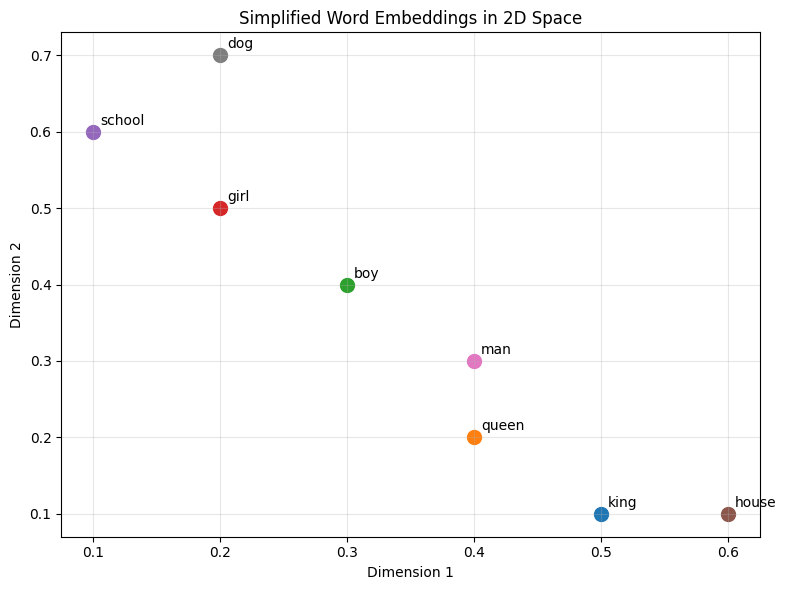

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embedding.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### measure similarity

In [41]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0
    
    return dot_product / (norm_vec1 * norm_vec2)

In [12]:
cosine_similarity(word_embedding["king"], word_embedding["queen"])

np.float64(0.9647638212377321)

In [13]:
cosine_similarity(word_embedding["king"], word_embedding["boy"])

np.float64(0.7452413135250993)

In [14]:
cosine_similarity(word_embedding["dog"], word_embedding["queen"])

np.float64(0.6757246285173464)

### creat embedding model

#### hugging face and openai model

#### hugging face

In [56]:
from langchain_huggingface import HuggingFaceEmbeddings
embedding=HuggingFaceEmbeddings(model_name="sentence-transformers/distiluse-base-multilingual-cased-v2")
embedding

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1504.88it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/distiluse-base-multilingual-cased-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [57]:
text="hello , im ai engineer and i want to learn more about ai and machine learning!"
embeded_text=embedding.embed_query(text)
embeded_text


[0.003576224436983466,
 -0.008983435109257698,
 -0.01007844414561987,
 -0.02059098705649376,
 -0.07632207125425339,
 -0.01128222793340683,
 0.04166637733578682,
 -0.014009830541908741,
 -0.05515095219016075,
 -0.044092658907175064,
 -0.012026899494230747,
 0.019475817680358887,
 0.05019870027899742,
 -0.12108726054430008,
 0.01234180387109518,
 -0.00868946686387062,
 0.029992276802659035,
 0.0516662560403347,
 -0.019345011562108994,
 0.07713662832975388,
 0.052554644644260406,
 -0.05139867961406708,
 0.016445383429527283,
 0.03551933169364929,
 0.054140157997608185,
 0.05922864004969597,
 0.03983981907367706,
 -0.040230028331279755,
 -0.006012498401105404,
 0.009437098167836666,
 0.057042691856622696,
 -0.009175899438560009,
 0.007151437923312187,
 -0.09579909592866898,
 0.020822422578930855,
 -0.03961510956287384,
 -0.03333059325814247,
 0.0296265110373497,
 0.060742538422346115,
 -0.030611947178840637,
 0.03409639373421669,
 0.01827356405556202,
 -0.05783478915691376,
 0.071302987635

In [58]:
sentences=[
    "I love machine learning and artificial intelligence.",
    "The cat is on the roof.",
    "Artificial intelligence is transforming the world.",
    "The dog is barking loudly.",
    "I enjoy learning new programming languages.",
        ]

In [68]:
embeded_sentences=embedding.embed_documents(sentences)
embeded_sentences

[[0.029079530388116837,
  -0.028037775307893753,
  -0.0088701406493783,
  0.003949156031012535,
  -0.07235315442085266,
  -0.008431305177509785,
  0.03374382108449936,
  -0.002076065866276622,
  -0.046965837478637695,
  -0.007900942116975784,
  0.002692568115890026,
  0.07699687033891678,
  0.0698021799325943,
  -0.05880174785852432,
  0.03741293400526047,
  -0.010861915536224842,
  0.08061467111110687,
  0.04068026691675186,
  -0.07107196748256683,
  0.050668612122535706,
  0.06384312361478806,
  -0.056921519339084625,
  -0.028774648904800415,
  0.06335601955652237,
  0.02329264022409916,
  0.08397920429706573,
  0.030574752017855644,
  -0.04837685450911522,
  -0.03851572424173355,
  0.03345024213194847,
  -0.011022888123989105,
  -0.03672204539179802,
  0.04293890297412872,
  -0.024683590978384018,
  -0.047143224626779556,
  -0.04801582172513008,
  -0.060334738343954086,
  0.024775434285402298,
  0.034062594175338745,
  -0.10387997329235077,
  -0.0250572357326746,
  -0.01105540990829

In [60]:
ask="السلام عليكم ورحمة الله وبركاته"
response=", وعليكم السلام ورحمة الله وبركاته"
embeded_ask=embedding.embed_query(ask)
embeded_response=embedding.embed_query(response)
similarity=cosine_similarity(embeded_ask, embeded_response)
similarity


np.float64(0.8632441114471945)

In [61]:
question="What is the capital of France?"
answer="i enjoy learning new programming languages."
answer2="Paris is the capital of France."
answer3="paris"

embeded_question=embedding.embed_query(question)
embeded_answer=embedding.embed_query(answer)
embeded_answer2=embedding.embed_query(answer2)
embeded_answer3=embedding.embed_query(answer3)
similarity=cosine_similarity(embeded_question, embeded_answer)
similarity
similarity2=cosine_similarity(embeded_question, embeded_answer2)
similarity2
similarity3=cosine_similarity(embeded_question, embeded_answer3)
similarity3

np.float64(0.24401508598839722)

#### openAi

In [62]:
def semantic_search(query, documents, embedding):
    embeded_query=embedding.embed_query(query)
    document_embeddings = embedding.embed_documents(documents)
    
    similarities = [cosine_similarity(embeded_query, doc_emb) for doc_emb in document_embeddings]
    
    ranked_documents = sorted(zip(documents, similarities), key=lambda x: x[1], reverse=True)
    
    return ranked_documents

In [63]:
query="what transforming the world?"
document=[
    "I love machine learning and artificial intelligence.",
    "Artificial intelligence is transforming the world.",
    "The cat is on the roof.",
    "The dog is barking loudly.",
    "I enjoy learning new programming languages.",
        
        ]

In [64]:
semantic_search(query, document, embedding)

[('Artificial intelligence is transforming the world.',
  np.float64(0.5297298975586415)),
 ('The dog is barking loudly.', np.float64(0.06255596619681388)),
 ('I love machine learning and artificial intelligence.',
  np.float64(0.04792655981491072)),
 ('I enjoy learning new programming languages.',
  np.float64(0.014539741823603763)),
 ('The cat is on the roof.', np.float64(-0.012999902845121022))]

In [65]:
doc = [
    "طباعة طلب الاستخراج - صورة البطاقة - صورة شهادة الميلاد - صورة شخصية - فايل شفاف - اذن دفع من شئون خريجين",
    "توجد فى الجامعة كلية تكنولوجيا الصناعة والطاقة وتحتوى على قسم تكنولوجيا المعلومات وقسم تكنولوجيا شبكات النقل والتوزيع الكهربائية وقسم تكنولوجيا الأجهزة الكهربائية والإلكترونية وقسم التصنيع الغذائى وكلية العلوم الصحية التطبيقية وتحتوى على قسم الإنتاج الدوائى وقسم تركيبات الاسنان وقسم المعلوماتية الصحية",
]
query="ما هى الكليات المتاحة فى الجامعة"

In [66]:
semantic_search(query, doc, embedding)

[('توجد فى الجامعة كلية تكنولوجيا الصناعة والطاقة وتحتوى على قسم تكنولوجيا المعلومات وقسم تكنولوجيا شبكات النقل والتوزيع الكهربائية وقسم تكنولوجيا الأجهزة الكهربائية والإلكترونية وقسم التصنيع الغذائى وكلية العلوم الصحية التطبيقية وتحتوى على قسم الإنتاج الدوائى وقسم تركيبات الاسنان وقسم المعلوماتية الصحية',
  np.float64(0.21349715519734225)),
 ('طباعة طلب الاستخراج - صورة البطاقة - صورة شهادة الميلاد - صورة شخصية - فايل شفاف - اذن دفع من شئون خريجين',
  np.float64(-0.019030518493620568))]

False
